# New section

In [8]:

# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_theme(style="whitegrid")


In [9]:
# ============================================================
# 2. UPLOAD AND LOAD DATASET
# ============================================================

from google.colab import files

uploaded = files.upload()

df = pd.read_csv("employees.csv")

print("Dataset loaded successfully!")

# Display first 5 rows
df.head()

Saving employees.csv to employees (3).csv
Dataset loaded successfully!


,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services


In [10]:

# ============================================================
# 3. DATA UNDERSTANDING
# ============================================================

# Number of rows and columns
print("Dataset Shape:", df.shape)

# Column names
print("\nColumn Names:")
print(df.columns.tolist())

# Data types
print("\nData Types:")
print(df.dtypes)

# Dataset information
print("\nDataset Information:")
df.info()

# First 5 rows
print("\nFirst 5 Rows:")
display(df.head())

# Last 5 rows
print("\nLast 5 Rows:")
display(df.tail())

Dataset Shape: (1000, 8)

Column Names:
['First Name', 'Gender', 'Start Date', 'Last Login Time', 'Salary', 'Bonus %', 'Senior Management', 'Team']

Data Types:
First Name            object
Gender                object
Start Date            object
Last Login Time       object
Salary                 int64
Bonus %              float64
Senior Management     object
Team                  object
dtype: object

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   First Name         933 non-null    object 
 1   Gender             855 non-null    object 
 2   Start Date         1000 non-null   object 
 3   Last Login Time    1000 non-null   object 
 4   Salary             1000 non-null   int64  
 5   Bonus %            1000 non-null   float64
 6   Senior Management  933 non-null    object 
 7   Team               957 non-nu

,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
0,Douglas,Male,8/6/1993,12:42 PM,97308,6.945,True,Marketing
1,Thomas,Male,3/31/1996,6:53 AM,61933,4.170,True,NaN
2,Maria,Female,4/23/1993,11:17 AM,130590,11.858,False,Finance
3,Jerry,Male,3/4/2005,1:00 PM,138705,9.340,True,Finance
4,Larry,Male,1/24/1998,4:47 PM,101004,1.389,True,Client Services



Last 5 Rows:


,First Name,Gender,Start Date,Last Login Time,Salary,Bonus %,Senior Management,Team
995,Henry,NaN,11/23/2014,6:09 AM,132483,16.655,False,Distribution
996,Phillip,Male,1/31/1984,6:30 AM,42392,19.675,False,Finance
997,Russell,Male,5/20/2013,12:39 PM,96914,1.421,False,Product
998,Larry,Male,4/20/2013,4:45 PM,60500,11.985,False,Business Development
999,Albert,Male,5/15/2012,6:24 PM,129949,10.169,True,Sales


In [11]:
# ============================================================
# 4. DATA QUALITY CHECK
# ============================================================

# Missing values
print("Missing Values:")
display(df.isnull().sum())

# Duplicate rows
print("Number of Duplicate Rows:", df.duplicated().sum())

# Number of unique values
print("\nUnique Values:")
print("Gender:", df["Gender"].nunique())
print("Teams:", df["Team"].nunique())


Missing Values:


,0
First Name,67
Gender,145
Start Date,0
Last Login Time,0
Salary,0
Bonus %,0
Senior Management,67
Team,43


Number of Duplicate Rows: 0

Unique Values:
Gender: 2
Teams: 10


In [12]:

# ============================================================
# 5. DATA CLEANING
# ============================================================

# Convert Start Date to datetime
df["Start Date"] = pd.to_datetime(
    df["Start Date"],
    errors="coerce"
)

# Remove duplicate records
df = df.drop_duplicates()

print("Dataset Shape After Cleaning:", df.shape)

# Check missing values again
print("\nMissing Values After Cleaning:")
display(df.isnull().sum())


Dataset Shape After Cleaning: (1000, 8)

Missing Values After Cleaning:


,0
First Name,67
Gender,145
Start Date,0
Last Login Time,0
Salary,0
Bonus %,0
Senior Management,67
Team,43


In [13]:
# ============================================================
# 6. FEATURE ENGINEERING
# ============================================================

# Extract Start Year
df["Start Year"] = df["Start Date"].dt.year

# Calculate Years of Service
current_year = 2026

df["Years of Service"] = (
    current_year - df["Start Year"]
)

# Display new features
display(
    df[
        [
            "First Name",
            "Start Date",
            "Start Year",
            "Years of Service"
        ]
    ].head()
)

,First Name,Start Date,Start Year,Years of Service
0,Douglas,1993-08-06,1993,33
1,Thomas,1996-03-31,1996,30
2,Maria,1993-04-23,1993,33
3,Jerry,2005-03-04,2005,21
4,Larry,1998-01-24,1998,28


In [14]:

# ============================================================
# 7. DESCRIPTIVE STATISTICS
# ============================================================

print("Salary Descriptive Statistics:")

display(df["Salary"].describe())

print("Average Salary:",
      round(df["Salary"].mean(), 2))

print("Median Salary:",
      round(df["Salary"].median(), 2))

print("Minimum Salary:",
      df["Salary"].min())

print("Maximum Salary:",
      df["Salary"].max())

print("Salary Standard Deviation:",
      round(df["Salary"].std(), 2))


Salary Descriptive Statistics:


,Salary
count,1000.000000
mean,90662.181000
std,32923.693342
min,35013.000000
25%,62613.000000
50%,90428.000000
75%,118740.250000
max,149908.000000


Average Salary: 90662.18
Median Salary: 90428.0
Minimum Salary: 35013
Maximum Salary: 149908
Salary Standard Deviation: 32923.69


In [15]:
# ============================================================
# 8. KEY WORKFORCE KPIs
# ============================================================

total_employees = len(df)

average_salary = df["Salary"].mean()

median_salary = df["Salary"].median()

highest_salary = df["Salary"].max()

average_bonus = df["Bonus %"].mean()

number_of_teams = df["Team"].nunique()

average_years_service = df["Years of Service"].mean()

print("======================================")
print("         WORKFORCE KPIs")
print("======================================")

print("Total Employees:",
      total_employees)

print("Average Salary: £",
      round(average_salary, 2))

print("Median Salary: £",
      round(median_salary, 2))

print("Highest Salary: £",
      highest_salary)

print("Average Bonus %:",
      round(average_bonus, 2))

print("Number of Teams:",
      number_of_teams)

print("Average Years of Service:",
      round(average_years_service, 2))

         WORKFORCE KPIs
Total Employees: 1000
Average Salary: £ 90662.18
Median Salary: £ 90428.0
Highest Salary: £ 149908
Average Bonus %: 10.21
Number of Teams: 10
Average Years of Service: 27.55


Employees by Team:


,count
Team,
Client Services,106
Finance,102
Business Development,101
Marketing,98
Product,95
Sales,94
Engineering,92
Human Resources,91
Distribution,90


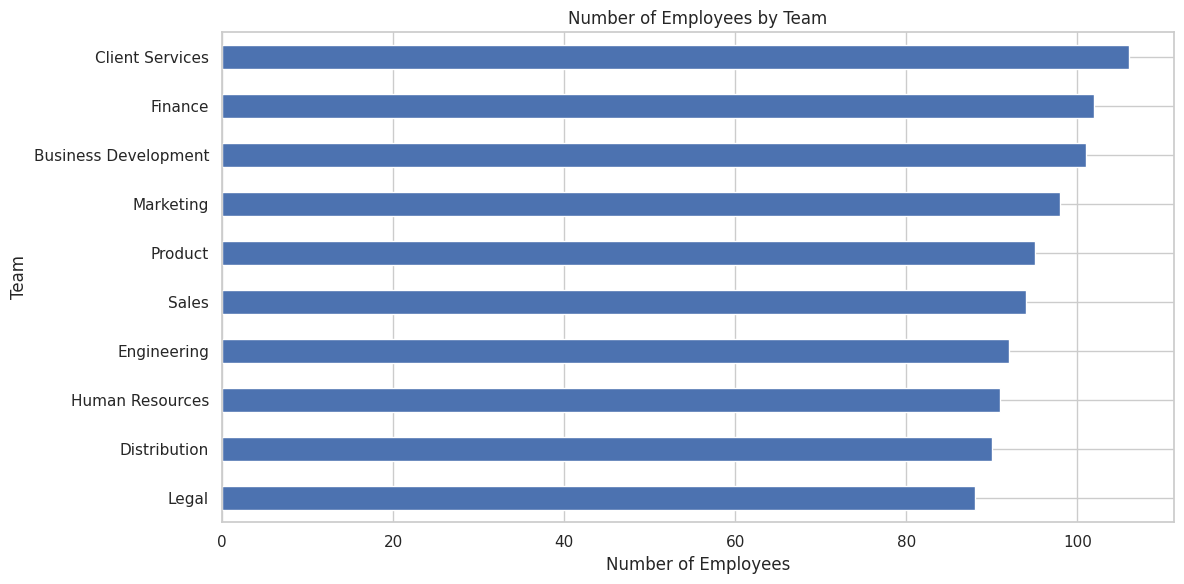

In [16]:
# ============================================================
# 9. EMPLOYEES BY TEAM
# ============================================================

team_counts = df["Team"].value_counts()

print("Employees by Team:")

display(team_counts)

plt.figure(figsize=(12, 6))

team_counts.sort_values().plot(
    kind="barh"
)

plt.title("Number of Employees by Team")

plt.xlabel("Number of Employees")

plt.ylabel("Team")

plt.tight_layout()

plt.show()

Employees by Gender:


,count
Gender,
Female,431
Male,424


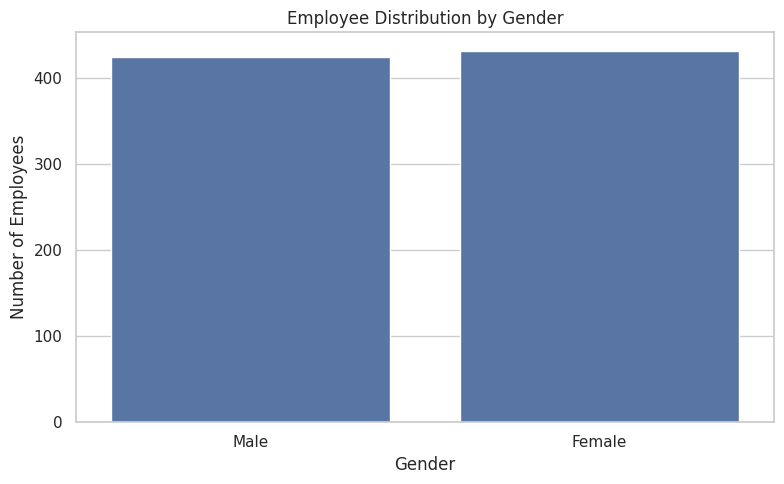

In [17]:
# ============================================================
# 10. EMPLOYEES BY GENDER
# ============================================================

gender_counts = df["Gender"].value_counts()

print("Employees by Gender:")

display(gender_counts)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Gender"
)

plt.title("Employee Distribution by Gender")

plt.xlabel("Gender")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.show()



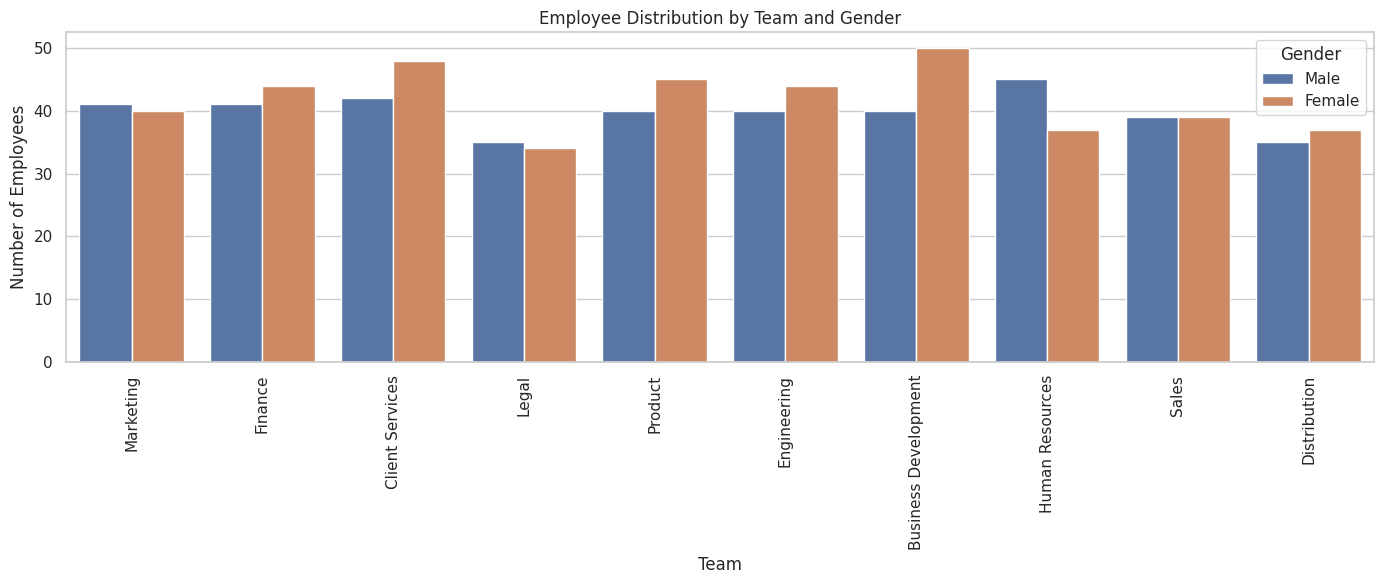

In [18]:
# ============================================================
# 11. TEAM AND GENDER DISTRIBUTION
# ============================================================

plt.figure(figsize=(14, 6))

sns.countplot(
    data=df,
    x="Team",
    hue="Gender"
)

plt.title(
    "Employee Distribution by Team and Gender"
)

plt.xlabel("Team")

plt.ylabel("Number of Employees")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()


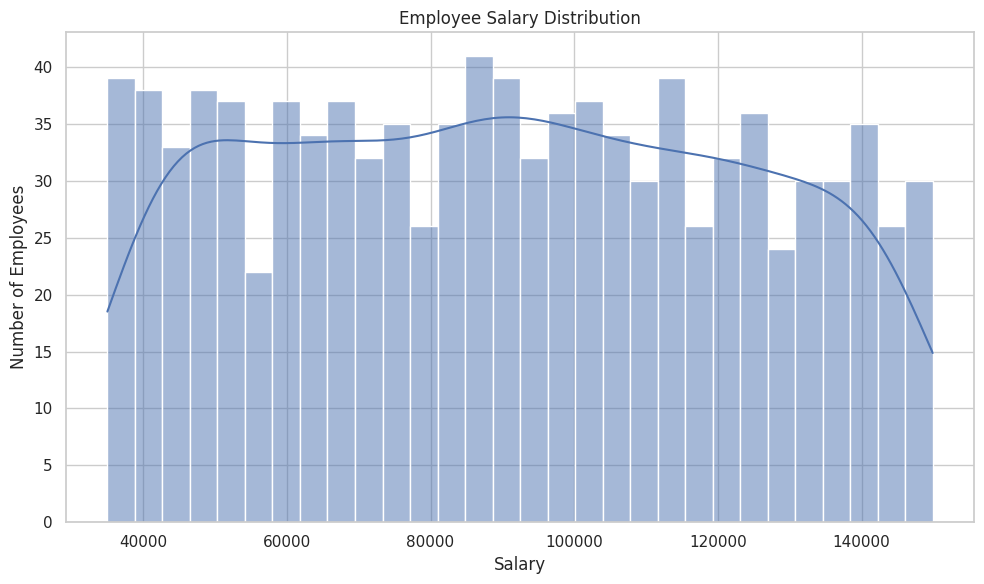

In [19]:
# ============================================================
# 12. SALARY DISTRIBUTION
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Salary",
    bins=30,
    kde=True
)

plt.title("Employee Salary Distribution")

plt.xlabel("Salary")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.show()


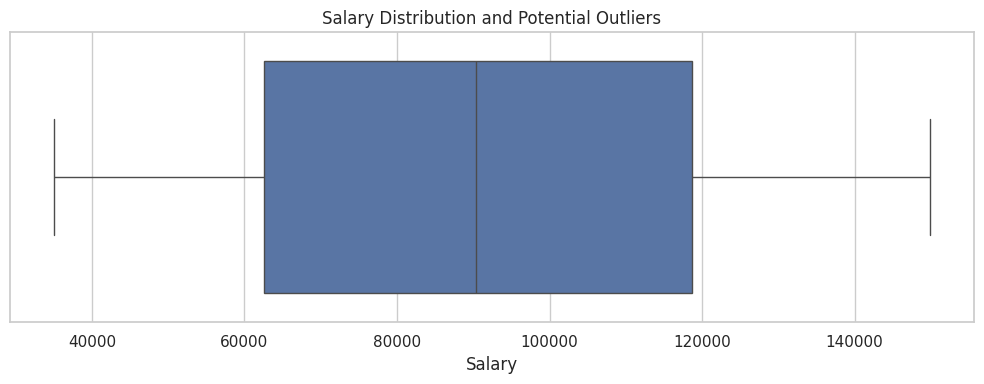

In [20]:
# ============================================================
# 13. SALARY BOXPLOT
# ============================================================

plt.figure(figsize=(10, 4))

sns.boxplot(
    data=df,
    x="Salary"
)

plt.title(
    "Salary Distribution and Potential Outliers"
)

plt.xlabel("Salary")

plt.tight_layout()

plt.show()


Salary Statistics by Gender:


,Count,Mean,Median,Minimum,Maximum
Gender,,,,,
Male,424,91180.669811,90112.0,35013,148985
Female,431,90023.923434,89780.0,35381,149908


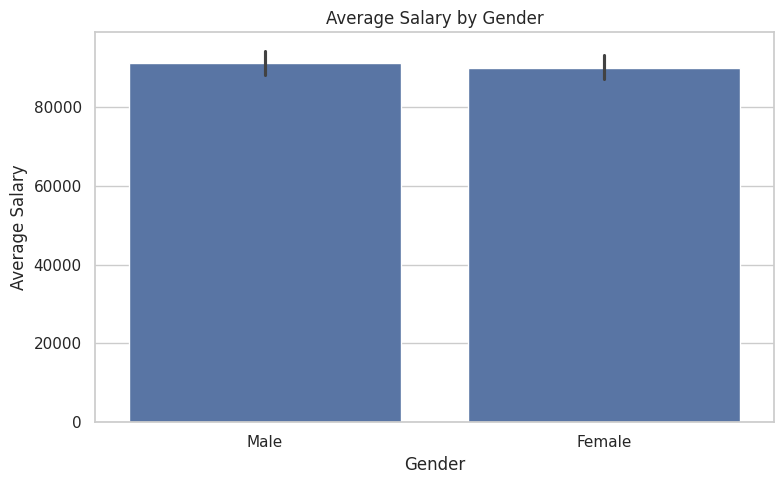

In [21]:
# ============================================================
# 14. SALARY BY GENDER
# ============================================================

gender_salary = (
    df.groupby("Gender")["Salary"]
      .agg(
          Count="count",
          Mean="mean",
          Median="median",
          Minimum="min",
          Maximum="max"
      )
      .sort_values(
          "Mean",
          ascending=False
      )
)

print("Salary Statistics by Gender:")

display(gender_salary)


plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Gender",
    y="Salary",
    estimator="mean"
)

plt.title("Average Salary by Gender")

plt.xlabel("Gender")

plt.ylabel("Average Salary")

plt.tight_layout()

plt.show()

Salary Statistics by Team:


,Employees,Average,Median,Standard_Deviation,Minimum,Maximum
Team,,,,,,
Engineering,92,94269.195652,95273.0,32349.531179,36946,147362
Finance,102,92219.480392,88873.5,34475.515066,35381,149908
Sales,94,92173.436170,91238.5,32202.944274,35802,149654
Business Development,101,91866.316832,93997.0,33461.860802,36844,147417
Human Resources,91,90944.527473,93022.0,33107.945736,35203,149903
Marketing,98,90435.591837,85381.5,34175.230632,36643,149456
Legal,88,89303.613636,87994.5,32755.649720,35061,148985
Product,95,88665.505263,88657.0,31997.406562,35013,149684
Distribution,90,88500.466667,86842.0,33538.473345,35575,149105


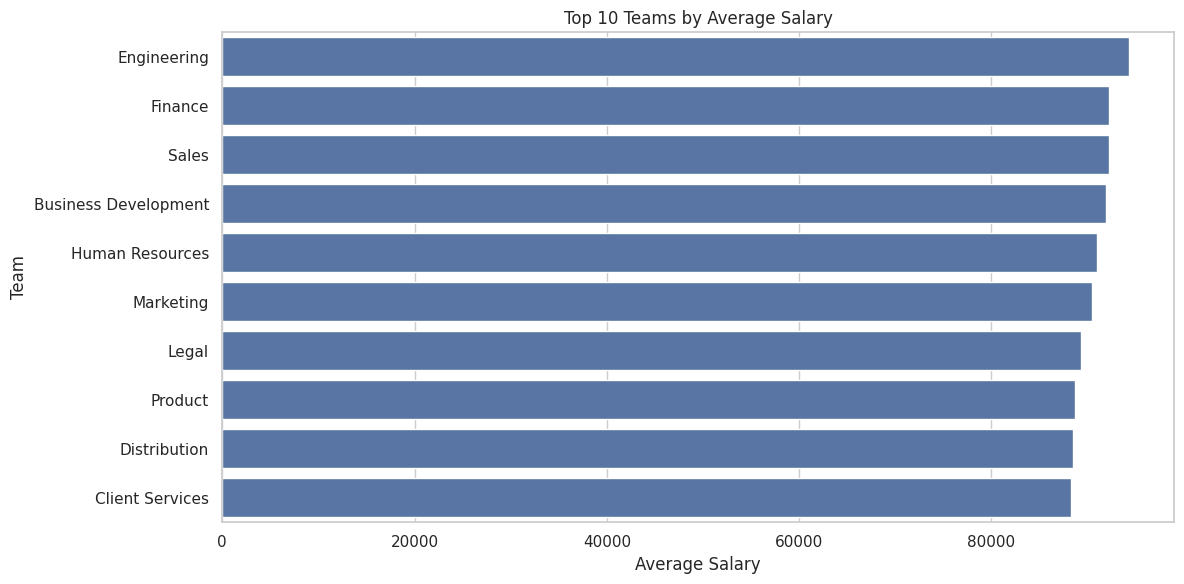

In [22]:
# ============================================================
# 15. SALARY BY TEAM
# ============================================================

team_salary = (
    df.groupby("Team")["Salary"]
      .agg(
          Employees="count",
          Average="mean",
          Median="median",
          Standard_Deviation="std",
          Minimum="min",
          Maximum="max"
      )
      .sort_values(
          "Average",
          ascending=False
      )
)

print("Salary Statistics by Team:")

display(team_salary)


# Top 10 teams by average salary
top_teams = team_salary.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(
    x=top_teams["Average"],
    y=top_teams.index
)

plt.title(
    "Top 10 Teams by Average Salary"
)

plt.xlabel("Average Salary")

plt.ylabel("Team")

plt.tight_layout()

plt.show()

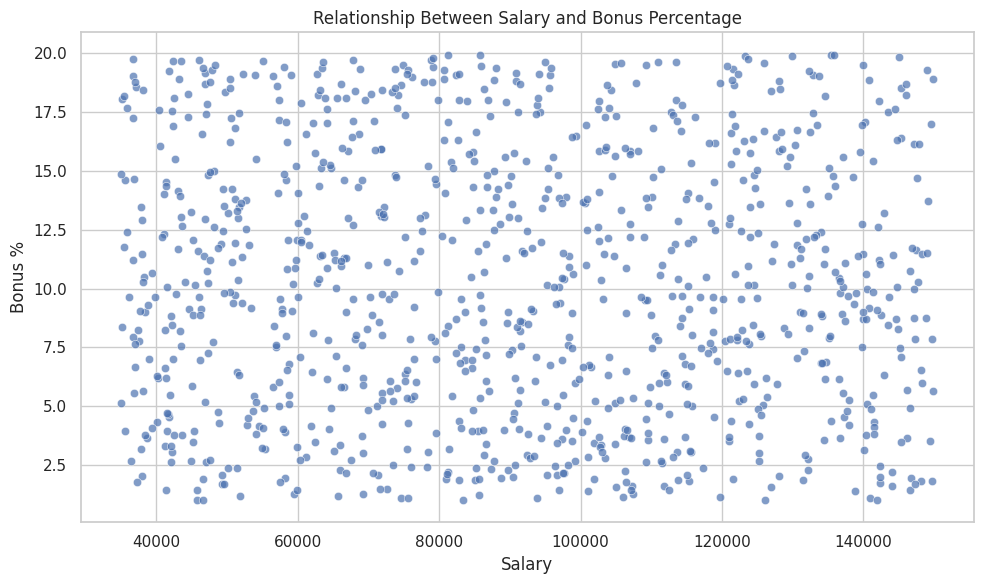

Correlation between Salary and Bonus %: -0.036


In [23]:
# ============================================================
# 16. SALARY VS BONUS
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Salary",
    y="Bonus %",
    alpha=0.7
)

plt.title(
    "Relationship Between Salary and Bonus Percentage"
)

plt.xlabel("Salary")

plt.ylabel("Bonus %")

plt.tight_layout()

plt.show()


# Calculate correlation
salary_bonus_correlation = (
    df["Salary"].corr(df["Bonus %"])
)

print(
    "Correlation between Salary and Bonus %:",
    round(salary_bonus_correlation, 3)
)



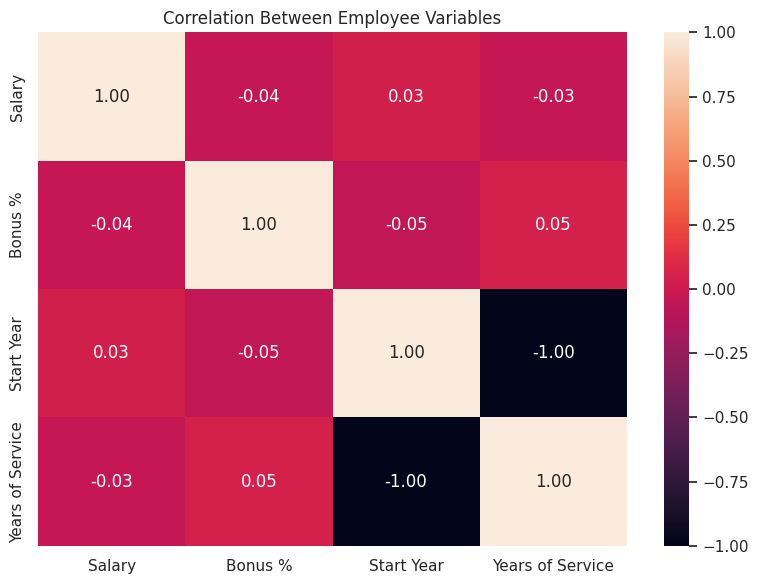

In [24]:
# ============================================================
# 17. CORRELATION HEATMAP
# ============================================================

numerical_columns = [
    "Salary",
    "Bonus %",
    "Start Year",
    "Years of Service"
]

correlation_matrix = (
    df[numerical_columns].corr()
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f"
)

plt.title(
    "Correlation Between Employee Variables"
)

plt.tight_layout()

plt.show()


Average Salary by Start Year:


,Start Year,Salary
0,1980,80666.333333
1,1981,90886.285714
2,1982,94920.500000
3,1983,87492.363636
4,1984,86175.406250
5,1985,87650.777778
6,1986,76063.928571
7,1987,93668.812500
8,1988,99480.960000
9,1989,104752.050000


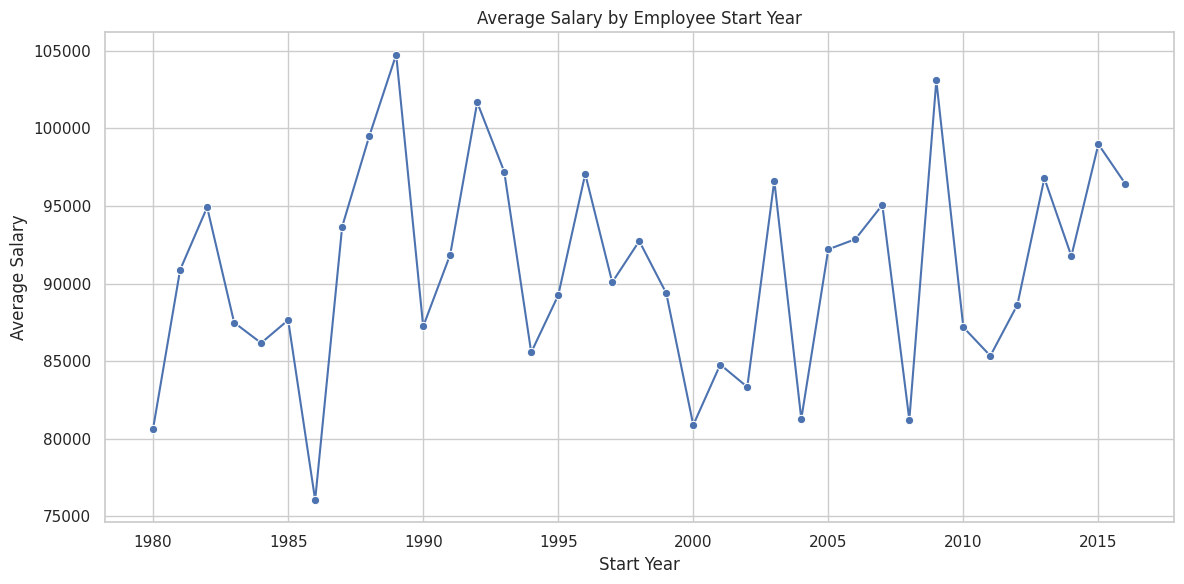

In [25]:
# ============================================================
# 18. AVERAGE SALARY BY START YEAR
# ============================================================

salary_by_year = (
    df.groupby("Start Year")["Salary"]
      .mean()
      .reset_index()
)

print("Average Salary by Start Year:")

display(salary_by_year)


plt.figure(figsize=(12, 6))

sns.lineplot(
    data=salary_by_year,
    x="Start Year",
    y="Salary",
    marker="o"
)

plt.title(
    "Average Salary by Employee Start Year"
)

plt.xlabel("Start Year")

plt.ylabel("Average Salary")

plt.tight_layout()

plt.show()


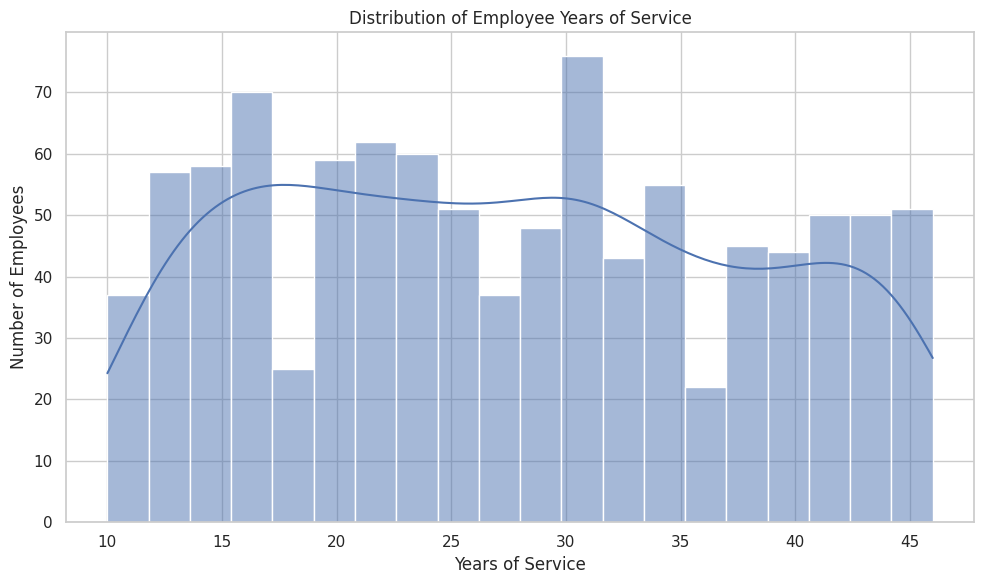

In [26]:
# ============================================================
# 19. YEARS OF SERVICE
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Years of Service",
    bins=20,
    kde=True
)

plt.title(
    "Distribution of Employee Years of Service"
)

plt.xlabel("Years of Service")

plt.ylabel("Number of Employees")

plt.tight_layout()

plt.show()

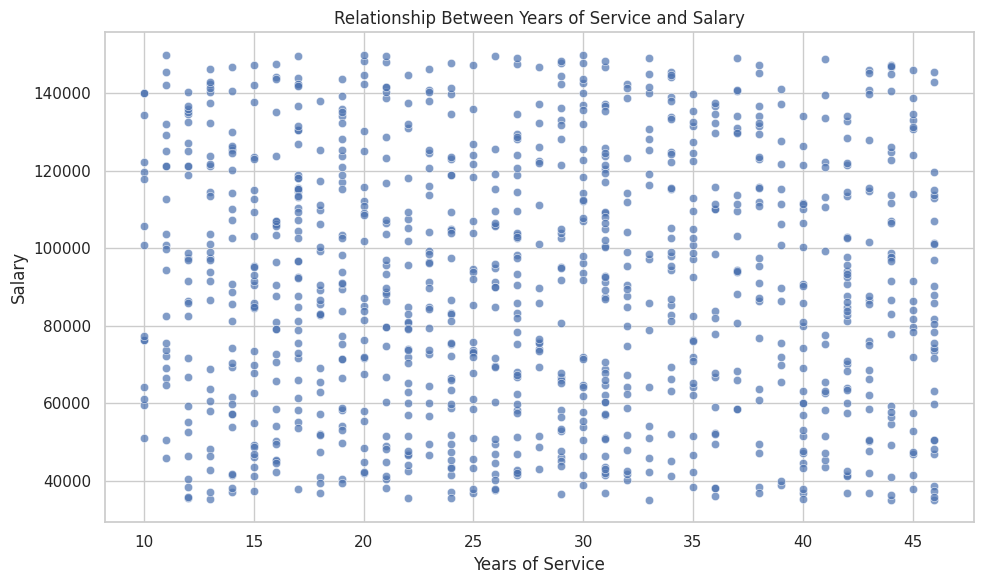

In [27]:
# ============================================================
# 20. YEARS OF SERVICE VS SALARY
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Years of Service",
    y="Salary",
    alpha=0.7
)

plt.title(
    "Relationship Between Years of Service and Salary"
)

plt.xlabel("Years of Service")

plt.ylabel("Salary")

plt.tight_layout()

plt.show()

In [28]:
# ============================================================
# 21. HIGH-EARNING EMPLOYEES
# ============================================================

high_earners = df[
    df["Salary"] > 100000
]

print(
    "Number of Employees Earning More Than £100,000:",
    len(high_earners)
)

display(
    high_earners[
        [
            "First Name",
            "Team",
            "Gender",
            "Salary",
            "Bonus %"
        ]
    ]
    .sort_values(
        "Salary",
        ascending=False
    )
)



Number of Employees Earning More Than £100,000: 409


,First Name,Team,Gender,Salary,Bonus %
644,Katherine,Finance,Female,149908,18.912
429,Rose,Human Resources,Female,149903,5.630
828,Cynthia,Product,Female,149684,7.864
186,NaN,Sales,Female,149654,1.825
160,Kathy,Finance,Female,149563,16.991
...,...,...,...,...,...
98,Tina,Marketing,Female,100705,16.961
21,Matthew,Marketing,Male,100612,13.645
660,Mary,Distribution,NaN,100341,6.662
261,Marie,Product,Female,100308,13.677


In [29]:
# ============================================================
# 22. TOP 10 HIGHEST-PAID EMPLOYEES
# ============================================================

top_10_earners = (
    df.nlargest(
        10,
        "Salary"
    )
    [
        [
            "First Name",
            "Team",
            "Gender",
            "Salary",
            "Bonus %"
        ]
    ]
)

print("Top 10 Highest-Paid Employees:")

display(top_10_earners)

Top 10 Highest-Paid Employees:


,First Name,Team,Gender,Salary,Bonus %
644,Katherine,Finance,Female,149908,18.912
429,Rose,Human Resources,Female,149903,5.630
828,Cynthia,Product,Female,149684,7.864
186,NaN,Sales,Female,149654,1.825
160,Kathy,Finance,Female,149563,16.991
740,Russell,Marketing,NaN,149456,3.533
793,Andrea,Distribution,Female,149105,13.707
981,James,Legal,Male,148985,19.280
800,Clarence,Product,Male,148941,11.517
844,Maria,Legal,NaN,148857,8.738


In [30]:
# ============================================================
# 23. TEAM WORKFORCE SUMMARY
# ============================================================

team_summary = (
    df.groupby("Team")
      .agg(
          Employees=("Team", "size"),
          Average_Salary=("Salary", "mean"),
          Median_Salary=("Salary", "median"),
          Average_Bonus=("Bonus %", "mean"),
          Average_Years_Service=(
              "Years of Service",
              "mean"
          )
      )
      .sort_values(
          "Average_Salary",
          ascending=False
      )
)

print("Team Workforce Summary:")

display(team_summary)


Team Workforce Summary:


,Employees,Average_Salary,Median_Salary,Average_Bonus,Average_Years_Service
Team,,,,,
Engineering,92,94269.195652,95273.0,10.462989,25.858696
Finance,102,92219.480392,88873.5,10.186873,27.852941
Sales,94,92173.436170,91238.5,10.116915,28.510638
Business Development,101,91866.316832,93997.0,10.572376,25.900990
Human Resources,91,90944.527473,93022.0,9.993879,28.879121
Marketing,98,90435.591837,85381.5,10.353449,27.877551
Legal,88,89303.613636,87994.5,10.322830,27.136364
Product,95,88665.505263,88657.0,9.791484,28.189474
Distribution,90,88500.466667,86842.0,9.615644,26.488889


In [31]:
# ============================================================
# 24. FINAL BUSINESS METRICS
# ============================================================

highest_paid_team = (
    team_summary["Average_Salary"]
    .idxmax()
)

largest_team = (
    team_summary["Employees"]
    .idxmax()
)

print("======================================")
print("        KEY BUSINESS FINDINGS")
print("======================================")

print(
    f"Total employees: {total_employees:,}"
)

print(
    f"Number of teams: {number_of_teams}"
)

print(
    f"Average salary: £{average_salary:,.2f}"
)

print(
    f"Median salary: £{median_salary:,.2f}"
)

print(
    f"Highest salary: £{highest_salary:,.2f}"
)

print(
    f"Largest team: {largest_team}"
)

print(
    f"Highest average salary team: {highest_paid_team}"
)

print(
    f"Average bonus: {average_bonus:.2f}%"
)

print(
    f"Average years of service: "
    f"{average_years_service:.1f}"
)

print(
    f"Salary/Bonus correlation: "
    f"{salary_bonus_correlation:.3f}"
)




        KEY BUSINESS FINDINGS
Total employees: 1,000
Number of teams: 10
Average salary: £90,662.18
Median salary: £90,428.00
Highest salary: £149,908.00
Largest team: Client Services
Highest average salary team: Engineering
Average bonus: 10.21%
Average years of service: 27.6
Salary/Bonus correlation: -0.036
